# Was SMOTE applied before the train/test split?

The reproduced results sit far below those reported in the reference paper, and the gap is
concentrated in the minority classes. This notebook tests one explanation.

Section III.E states that augmentation is done *"only on 80 % of training data, which are
selected randomly in each fold"*, which is what `reproduction.ipynb` implements. If instead
SMOTE had been applied to the **whole dataset before splitting**, synthetic minority samples
interpolated from training rows would also appear in the test set as near-duplicates, and
minority-class scores would be inflated.

Everything below is copied from `reproduction.ipynb` unchanged. The only variable is **when
SMOTE runs relative to the split**.

# Import libraries

In [34]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# Load data

In [35]:
df = pd.read_parquet("../data/ptbxl100_single.parquet")
df.head()

,patient_id,diagnostic_superclass,signal
ecg_id,,,
1,15709.0,NORM,"[-0.119, -0.055, 0.064, 0.086, -0.091, 0.004, ..."
2,13243.0,NORM,"[0.004, 0.138, 0.134, -0.072, -0.065, 0.136, -..."
3,20372.0,NORM,"[-0.029, -0.079, -0.049, 0.054, 0.011, -0.064,..."
4,17014.0,NORM,"[-0.054, -0.138, -0.083, 0.096, 0.015, -0.11, ..."
5,17448.0,NORM,"[-0.034, -0.574, -0.54, 0.304, 0.253, -0.556, ..."


In [36]:
LEADS = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]

X = np.stack(df["signal"].values)
y = df["diagnostic_superclass"]

print(f"X: {X.shape}")
print(f"y: {y.shape}  {y.nunique()} classes")

X: (16244, 12000)
y: (16244,)  5 classes


# Feature extraction

Opossing to the paper, we shall start with `(21837, 12, 1000)` and convert *"(21837, 12000)"*, which is `leadmajor`, meaning that, one single continuous 10-second ECG record is placed one after another, rather than interleaving sample by sample, as in `timemajor`.

Following III.D, the script finds the R peaks with `ecg_peaks()`, locates P, Q, S and T around them with `ecg_delineate(method = "peak")`, and assembles the sixteen features, i.e. five peak locations, five peak amplitudes, and six intervals (PQ, ST, QT, PR, RR, QRS).

**Run the first block** if the parquet is already there. **If it is not, run the second block first**, then come back to the first.

In [37]:
# Block 1: the parquet already exists.
ORDERING = "timemajor"

features = pd.read_parquet(f"../data/features_{ORDERING}.parquet")
FEATURES = [c for c in features.columns if c != "label"]

n_beats = features["R_loc"].map(len)

print(f"loaded {features.shape[0]:,} records")
print(f"peaks per record: median {int(n_beats.median())}  min {n_beats.min()}  max {n_beats.max()}")

loaded 16,244 records
peaks per record: median 12  min 0  max 81


In [38]:
# Block 2: No parquet yet. Re-extracts from ptbxl100_single.parquet

# !python ../src/extract_nk_features.py leadmajor

In [39]:
shapes = []

for i in range(features.shape[0]):
    for j in range(features.shape[1] - 1):
        # print(i, j, features.iloc[i, j])
        shapes.append(features.iloc[i, j].shape)

np.unique(shapes)


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 58, 62, 63, 66, 68, 69, 71, 73, 75, 81])

In [40]:
features.head(2)

,P_loc,Q_loc,R_loc,S_loc,T_loc,P_amp,Q_amp,R_amp,S_amp,T_amp,PQ,ST,QT,PR,QRS,RR,label
ecg_id,,,,,,,,,,,,,,,,,
1,"[264.0, 1363.0, 2484.0, 3063.0, 3469.0, 3589.0...","[275.0, 1379.0, 2495.0, 3204.0, 3483.0, 3594.0...","[280.0, 1384.0, 2500.0, 3207.0, 3485.0, 3600.0...","[283.0, 1386.0, 2502.0, 3208.0, 3549.0, 3603.0...","[287.0, 1403.0, 2519.0, 3481.0, 3623.0, 3623.0...","[0.469, 0.225, 0.351, 0.081, 0.122, 0.227, 0.2...","[0.313, 0.194, 0.276, -0.114, -0.134, 0.059, 0...","[0.248, 0.37, 0.387, 0.082, 0.08, 0.628, 0.641...","[-0.953, -0.367, -0.407, -0.09, -0.056, -0.525...","[0.382, 0.405, 0.414, 0.142, 0.444, 0.444, 0.4...","[11.0, 16.0, 11.0, 141.0, 14.0, 5.0, 5.0, 6.0,...","[4.0, 17.0, 17.0, 273.0, 74.0, 20.0, 20.0, 152...","[12.0, 24.0, 24.0, 277.0, 140.0, 29.0, 29.0, 1...","[16.0, 21.0, 16.0, 144.0, 16.0, 11.0, 11.0, 12...","[8.0, 7.0, 7.0, 4.0, 66.0, 9.0, 9.0, 9.0, 8.0,...","[nan, 1104.0, 1116.0, 707.0, 278.0, 115.0, 111...",NORM
2,"[1183.0, 2769.0, 4387.0, 6029.0, 7525.0, 8965....","[1203.0, 2779.0, 4407.0, 6031.0, 7531.0, 8971....","[1205.0, 2781.0, 4409.0, 6033.0, 7533.0, 8973....","[1207.0, 2791.0, 4411.0, 6036.0, 7536.0, 8976....","[1221.0, 2795.0, 4425.0, 6045.0, 7545.0, 8985....","[0.462, 1.079, 0.368, 0.769, 0.87, 1.225, 0.44...","[-0.865, -2.819, -0.804, -2.221, -2.472, -2.62...","[0.94, 2.188, 0.751, 1.905, 1.753, 2.076, 0.96...","[-2.246, -2.316, -2.11, 0.17, 0.353, 0.053, -2...","[1.86, 0.468, 1.928, 1.707, 1.784, 0.978, 1.69...","[20.0, 10.0, 20.0, 2.0, 6.0, 6.0, 20.0, 10.0]","[14.0, 4.0, 14.0, 9.0, 9.0, 9.0, 2.0, 2.0]","[18.0, 16.0, 18.0, 14.0, 14.0, 14.0, 6.0, 6.0]","[22.0, 12.0, 22.0, 4.0, 8.0, 8.0, 22.0, 12.0]","[4.0, 12.0, 4.0, 5.0, 5.0, 5.0, 4.0, 4.0]","[nan, 1576.0, 1628.0, 1624.0, 1500.0, 1440.0, ...",NORM


## Visualisations

### Waveforms amplitudes and their peak locations

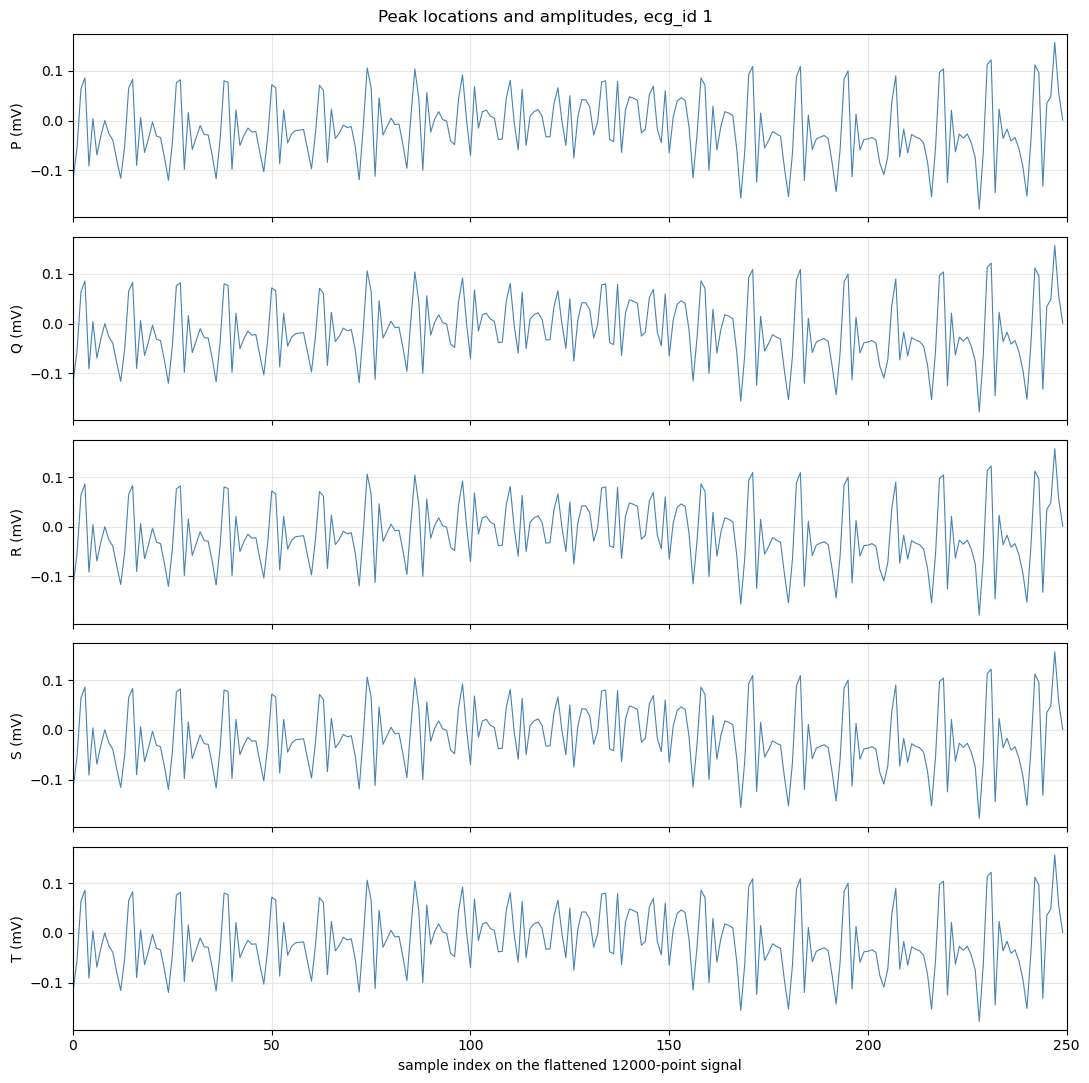

In [41]:
sample = features.iloc[0]

# Visualise five waveform amplitudes (in blue) and their peaks (in red)
WAVE_LABELS = ["P", "Q", "R", "S", "T"]

# `sample` is features.iloc[0]
signal = X[0]
window = 250

fig, axes = plt.subplots(len(WAVE_LABELS), 1, figsize = (11, 11), sharex = True)

for ax, wave in zip(axes, WAVE_LABELS):
    ax.plot(np.arange(window), signal[:window], color = "steelblue", linewidth = 0.8)

    location = sample[f"{wave}_loc"]
    amplitude = sample[f"{wave}_amp"]

    for x in location:
        ax.axvline(x, color = "firebrick", linestyle = "--", linewidth = 0.6, alpha = 1)

    ax.set_ylabel(f"{wave} (mV)")
    ax.set_xlim(0, window)
    ax.grid(alpha = 0.3)
    ax.set_axisbelow(True)

axes[-1].set_xlabel("sample index on the flattened 12000-point signal")
fig.suptitle(f"Peak locations and amplitudes, ecg_id {sample.name}")

plt.tight_layout()
plt.show()

### Visualisations of intervals/segments

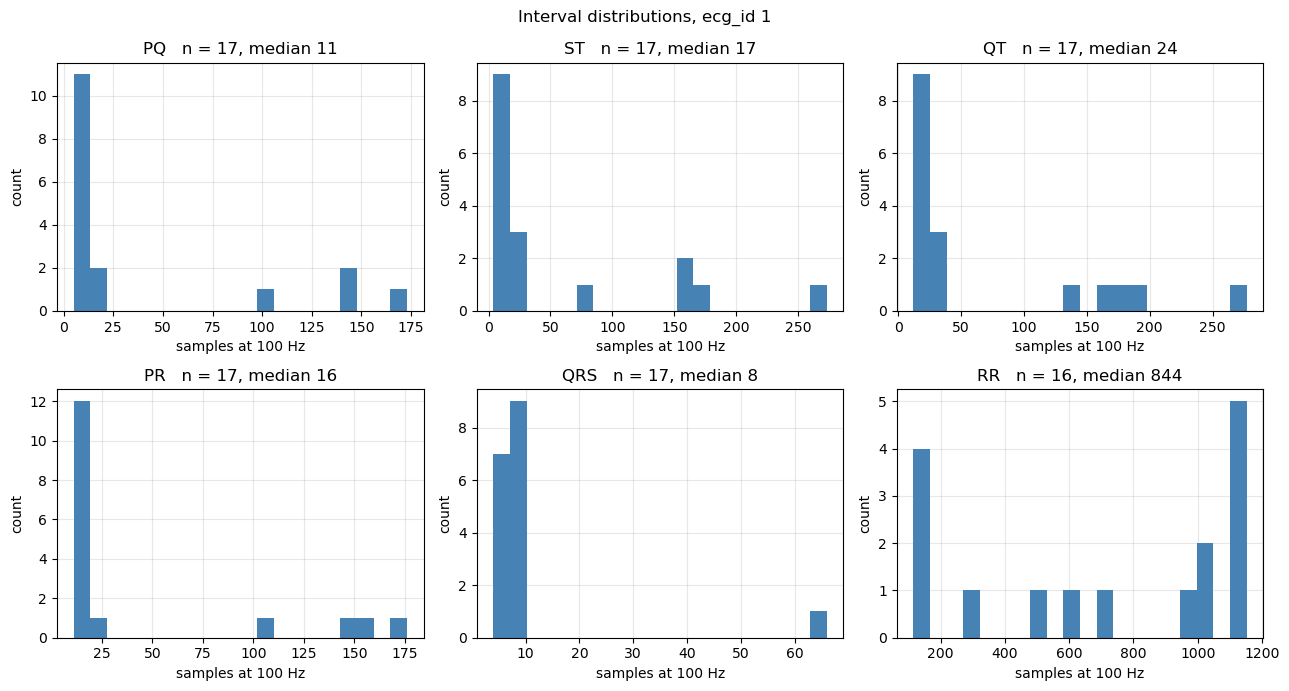

In [42]:
# Visualise the histogram of each interval PQ, ST, ....
INTERVALS = ["PQ", "ST", "QT", "PR", "QRS", "RR"]

fig, axes = plt.subplots(2, 3, figsize = (13, 7))

for ax, name in zip(axes.flatten(), INTERVALS):
    values = sample[name]
    values = values[~np.isnan(values)]

    ax.hist(values, bins = 20, color = "steelblue")

    ax.set_title(f"{name}   n = {len(values)}, median {np.median(values):.0f}")
    ax.set_xlabel("samples at 100 Hz")
    ax.set_ylabel("count")
    ax.grid(alpha = 0.3)
    ax.set_axisbelow(True)

fig.suptitle(f"Interval distributions, ecg_id {sample.name}")

plt.tight_layout()
plt.show()

# Data preparation

Identical to `reproduction.ipynb`: forward fill along the beat axis, equate lengths to the
median peak count carrying the last beat forward, stack, flatten, then forward fill down the
columns and drop any column that is NaN throughout.

## Difficulties verification

Difficulty 1 - subjects with every feature NaN: 280 (1.7%)
Difficulty 2 - distinct feature lengths: 67  (min 0, median 12, max 81)
Also         - records whose 16 features disagree in length: 157
               all of them have exactly one R-peak: True

mean share of NaN within each feature:
RR       0.111
T_loc    0.038
T_amp    0.038
ST       0.038
QT       0.038
S_loc    0.038
S_amp    0.038
QRS      0.038
P_loc    0.038
Q_loc    0.038
P_amp    0.038
Q_amp    0.038
PQ       0.038
PR       0.038
R_loc    0.017
R_amp    0.017


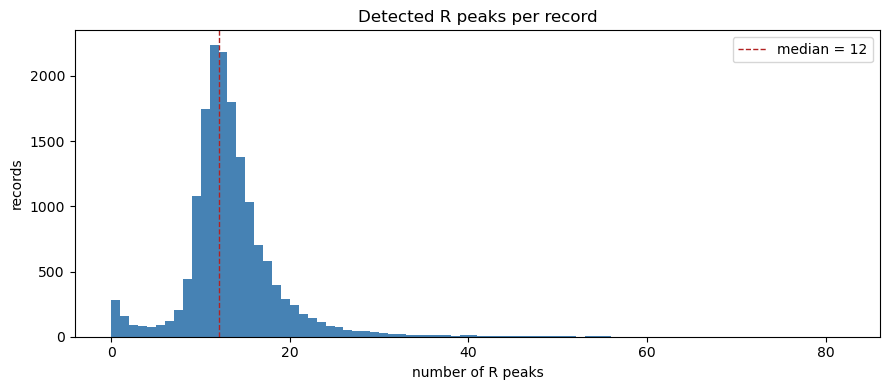

In [43]:
FEATURES = [c for c in features.columns if c != "label"]
lengths = features[FEATURES].map(len)

# Difficulty 1: "at some points, all the features for the particular subjects are NaN".
empty = features[FEATURES].map(
    lambda a: len(a) == 0 or bool(np.all(np.isnan(a)))).all(axis = 1)

print(f"Difficulty 1 - subjects with every feature NaN: {empty.sum():,} ({empty.mean():.1%})")

# Difficulty 2: "the length of extracted features for all the ECGs are not the same,
# which means all the recorded signals did not have equal no. of peaks".
n_beats = lengths["R_loc"]

print(f"Difficulty 2 - distinct feature lengths: {n_beats.nunique()}"
      f"  (min {n_beats.min()}, median {int(n_beats.median())}, max {n_beats.max()})")

# In some records, the sixteen features do not always share a length.
ragged = lengths.nunique(axis = 1) > 1

print(f"Also         - records whose 16 features disagree in length: {ragged.sum():,}")
print(f"               all of them have exactly one R-peak: "
      f"{bool((ragged == (n_beats == 1)).all())}")

print("\nmean share of NaN within each feature:")
print(features[FEATURES]
      .map(lambda a: float(np.mean(np.isnan(a))) if len(a) else 1.0)
      .mean().sort_values(ascending = False).round(3).to_string())


fig, ax = plt.subplots(figsize = (9, 4))

ax.hist(n_beats, bins = range(0, int(n_beats.max()) + 2), color = "steelblue")
ax.set_title("Detected R peaks per record")
ax.set_xlabel("number of R peaks")
ax.set_ylabel("records")
ax.axvline(int(n_beats.median()), color = "firebrick", linestyle = "--", linewidth = 1,
           label = f"median = {int(n_beats.median())}")
ax.legend()

plt.tight_layout()
plt.show()

## Forward fill and length equating

In [44]:
N_BEATS = int(n_beats.median())


def forward_fill(values):
    """Forward fill along the beat axis of one record."""
    if len(values) == 0:
        return values
    index = np.where(~np.isnan(values), np.arange(len(values)), 0)
    np.maximum.accumulate(index, out = index)
    return values[index]


def equate(values, length):
    """Truncate or pad one record to a common number of beats."""
    out = np.full(length, np.nan, dtype = np.float32)
    keep = min(len(values), length)
    if keep:
        out[:keep] = values[:keep]
        out[keep:] = values[keep - 1]     # forward fill past the last beat
    return out


cube = np.stack([
    np.stack([equate(forward_fill(features[c].iloc[i]), N_BEATS) for c in FEATURES])
    for i in range(len(features))
])

columns = [f"{c}_{k}" for c in FEATURES for k in range(N_BEATS)]
prepared = pd.DataFrame(cube.reshape(len(cube), -1), index = features.index,
                        columns = columns).ffill()

prepared = prepared.drop(columns = prepared.columns[prepared.isna().all()])

LABEL_ENCODING = {"NORM": 0, "MI": 1, "STTC": 2, "HYP": 3, "CD": 4}
CLASS_ORDER = sorted(LABEL_ENCODING.values())

target = features["label"].map(LABEL_ENCODING)

print(f"feature matrix: {prepared.shape}   NaN: {prepared.isna().sum().sum()}")
print("class counts:", dict(target.value_counts().sort_index()))

feature matrix: (16244, 191)   NaN: 0
class counts: {0: np.int64(9069), 1: np.int64(2532), 2: np.int64(2400), 3: np.int64(535), 4: np.int64(1708)}


# The two protocols

Both use the same classifiers at library defaults, the same 80/20 unstratified split with
`random_state = 42`, and the same scaling. They differ in one line.

**A - as published in III.E, and as implemented in `reproduction.ipynb`.** Split first, then
scale and resample inside the pipeline, so SMOTE only ever sees training rows.

**B - the hypothesis.** Scale and resample the whole dataset, *then* split. The test set now
contains synthetic minority rows built from records that are also in the training set.

In [45]:
CLASSIFIERS = {
    "KNN": KNeighborsClassifier(),
    "RF": RandomForestClassifier(random_state = 42, n_jobs = -1),
    "XGBoost": XGBClassifier(random_state = 42, n_jobs = -1),
    "GradientBoost": HistGradientBoostingClassifier(random_state = 42),
    "CatBoost": CatBoostClassifier(random_state = 42, verbose = 0),
    "AdaBoost": AdaBoostClassifier(random_state = 42)
}


def evaluate(actual, predicted):
    precision, recall, f1, _ = precision_recall_fscore_support(
        actual, predicted, labels = CLASS_ORDER, zero_division = 0)
    return pd.DataFrame({"precision": precision, "recall": recall, "f1": f1},
                        index = CLASS_ORDER)

## A - SMOTE inside the training fold (faithful)

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    prepared, target, test_size = 0.2, random_state = 42)

protocol_a = {}

for name, classifier in CLASSIFIERS.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state = 42)),
        ("classifier", classifier),
    ])
    pipeline.fit(X_train, y_train)
    predicted = pipeline.predict(X_test)

    protocol_a[name] = {"report": evaluate(y_test, predicted),
                        "accuracy": accuracy_score(y_test, predicted),
                        "predicted": predicted, "actual": y_test,
                        "proba": pipeline.predict_proba(X_test)}

    print(f"{name:5s} accuracy {protocol_a[name]['accuracy']:.3f}"
          f"   train {X_train.shape}  test {X_test.shape}")

KNN   accuracy 0.274   train (12995, 191)  test (3249, 191)
RF    accuracy 0.551   train (12995, 191)  test (3249, 191)
XGBoost accuracy 0.586   train (12995, 191)  test (3249, 191)
GradientBoost accuracy 0.595   train (12995, 191)  test (3249, 191)
CatBoost accuracy 0.587   train (12995, 191)  test (3249, 191)
AdaBoost accuracy 0.292   train (12995, 191)  test (3249, 191)


## B - SMOTE over the whole dataset, then split (hypothesis)

In [47]:
# The single change under test: resampling happens before the split, so synthetic
# minority rows are distributed across both sides of it.
X_all = StandardScaler().fit_transform(prepared)
X_resampled, y_resampled = SMOTE(random_state = 42).fit_resample(X_all, target)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_resampled, y_resampled, test_size = 0.2, random_state = 42)

protocol_b = {}

for name, classifier in CLASSIFIERS.items():
    model = classifier.__class__(**classifier.get_params())
    model.fit(X_train_b, y_train_b)
    predicted = model.predict(X_test_b)

    protocol_b[name] = {"report": evaluate(y_test_b, predicted),
                        "accuracy": accuracy_score(y_test_b, predicted),
                        "predicted": predicted, "actual": y_test_b,
                        "proba": model.predict_proba(X_test_b)}

    print(f"{name:5s} accuracy {protocol_b[name]['accuracy']:.3f}"
          f"   train {X_train_b.shape}  test {X_test_b.shape}")

KNN   accuracy 0.791   train (36276, 191)  test (9069, 191)
RF    accuracy 0.873   train (36276, 191)  test (9069, 191)
XGBoost accuracy 0.834   train (36276, 191)  test (9069, 191)
GradientBoost accuracy 0.799   train (36276, 191)  test (9069, 191)
CatBoost accuracy 0.811   train (36276, 191)  test (9069, 191)
AdaBoost accuracy 0.428   train (36276, 191)  test (9069, 191)


# Reproduced results: Protocol B only

Protocol B, presented the way the paper presents its own results, so the two are
like for like.

| here | paper |
| --- | --- |
| per-class table | Tables 6, 7, 9, 10, 11 (10-fold means) |
| summary table | Table 12 (classifier comparison) |
| confusion matrix | Figure 7 (20 % holdout) |
| ROC curves | Figure 8 (class-wise ROC-AUC) |

The tables come from 10-fold cross-validation and the figures from the 20 % holdout,
because that is how the paper produced each of them: section IV states the tables are
*"the mean of 10-fold cross-validation"*, while the confusion matrices are drawn from
*"20 % of testing data"*.

Cross-validation here keeps protocol B intact: the whole dataset is scaled and resampled
**once**, and the folds are cut from the resampled rows. The leak is the point - every
validation fold holds synthetic rows interpolated from rows in its own training set.

In [48]:
FOLDS = 10


def cross_validate(classifier, X, y, folds = FOLDS):
    """Mean per-class precision, recall and F1 over the folds of protocol B."""
    kfold = KFold(n_splits = folds, shuffle = True, random_state = 42)
    scores, accuracies = [], []

    for train_index, validation_index in kfold.split(X):
        model = clone(classifier)
        model.fit(X[train_index], y[train_index])
        predicted = model.predict(X[validation_index])

        actual = y[validation_index]
        precision, recall, f1, _ = precision_recall_fscore_support(
            actual, predicted, labels = CLASS_ORDER, zero_division = 0)

        scores.append(np.vstack([precision, recall, f1]))
        accuracies.append(accuracy_score(actual, predicted))

    table = pd.DataFrame(np.mean(scores, axis = 0).T, index = CLASS_ORDER,
                         columns = ["precision", "recall", "f1"])
    return table, float(np.mean(accuracies)), float(np.std(accuracies))


# X_resampled / y_resampled come from the protocol B cell above: already scaled and
# already SMOTE'd, so the folds inherit the leak rather than re-creating it.
labels = np.asarray(y_resampled)

crossvalidated_b = {}

for name, classifier in CLASSIFIERS.items():
    started = time.perf_counter()

    table, mean_accuracy, std_accuracy = cross_validate(classifier, X_resampled, labels)
    crossvalidated_b[name] = {"report": table, "accuracy": mean_accuracy,
                              "accuracy_std": std_accuracy}

    print(f"{name:14s} accuracy {mean_accuracy:.3f} +/- {std_accuracy:.3f}"
          f"   {time.perf_counter() - started:6.1f}s")

KNN            accuracy 0.799 +/- 0.004      4.5s
RF             accuracy 0.884 +/- 0.004     59.5s
XGBoost        accuracy 0.842 +/- 0.004     49.8s
GradientBoost  accuracy 0.805 +/- 0.006    155.0s
CatBoost       accuracy 0.818 +/- 0.005    413.9s
AdaBoost       accuracy 0.413 +/- 0.006    354.2s


In [49]:
# Tables 6, 7, 9, 10, 11 - per-class precision, recall and F1, averaged over the folds.
per_class = pd.concat({name: result["report"] for name, result in crossvalidated_b.items()},
                      names = ["classifier", "class"])

(per_class * 100).round(1)

precision  recall    f1
classifier    class                         
KNN           0           81.8    23.0  35.9
              1           73.4    90.8  81.2
              2           77.3    90.6  83.4
              3           92.4    99.9  96.0
              4           77.5    95.2  85.4
RF            0           81.3    75.4  78.2
              1           88.1    87.8  87.9
              2           86.7    88.7  87.7
              3           94.1    99.2  96.6
              4           91.0    90.8  90.9
XGBoost       0           70.9    87.2  78.2
              1           84.6    76.3  80.2
              2           84.3    76.2  80.0
              3           96.1    98.5  97.3
              4           88.3    83.0  85.5
GradientBoost 0           68.5    87.5  76.8
              1           79.6    69.8  74.4
              2           79.1    70.6  74.6
              3           93.6    97.6  95.6
              4           84.5    77.0  80.5
CatBoost      0           70.4    84.6  76.9
              1           81.2    73.1  76.9
              2           80.3    73.3  76.6
              3           92.5    98.0  95.2
              4           86.2    79.8  82.8
AdaBoost      0           43.4    38.6  40.6
              1           32.5    32.2  32.0
              2           31.5    32.3  31.6
              3           58.7    71.2  64.3
              4           37.5    32.1  34.4

In [50]:
# Table 12 - one row per classifier.
summary = pd.DataFrame({
    name: {
        "accuracy": result["accuracy"],
        "accuracy_std": result["accuracy_std"],
        "precision": result["report"]["precision"].mean(),
        "recall": result["report"]["recall"].mean(),
        "f1": result["report"]["f1"].mean(),
    }
    for name, result in crossvalidated_b.items()
}).T.sort_values("f1", ascending = False)

(summary * 100).round(1)

,accuracy,accuracy_std,precision,recall,f1
RF,88.4,0.4,88.2,88.4,88.3
XGBoost,84.2,0.4,84.8,84.2,84.3
CatBoost,81.8,0.5,82.1,81.8,81.7
GradientBoost,80.5,0.6,81.1,80.5,80.4
KNN,79.9,0.4,80.5,79.9,76.4
AdaBoost,41.3,0.6,40.7,41.3,40.6


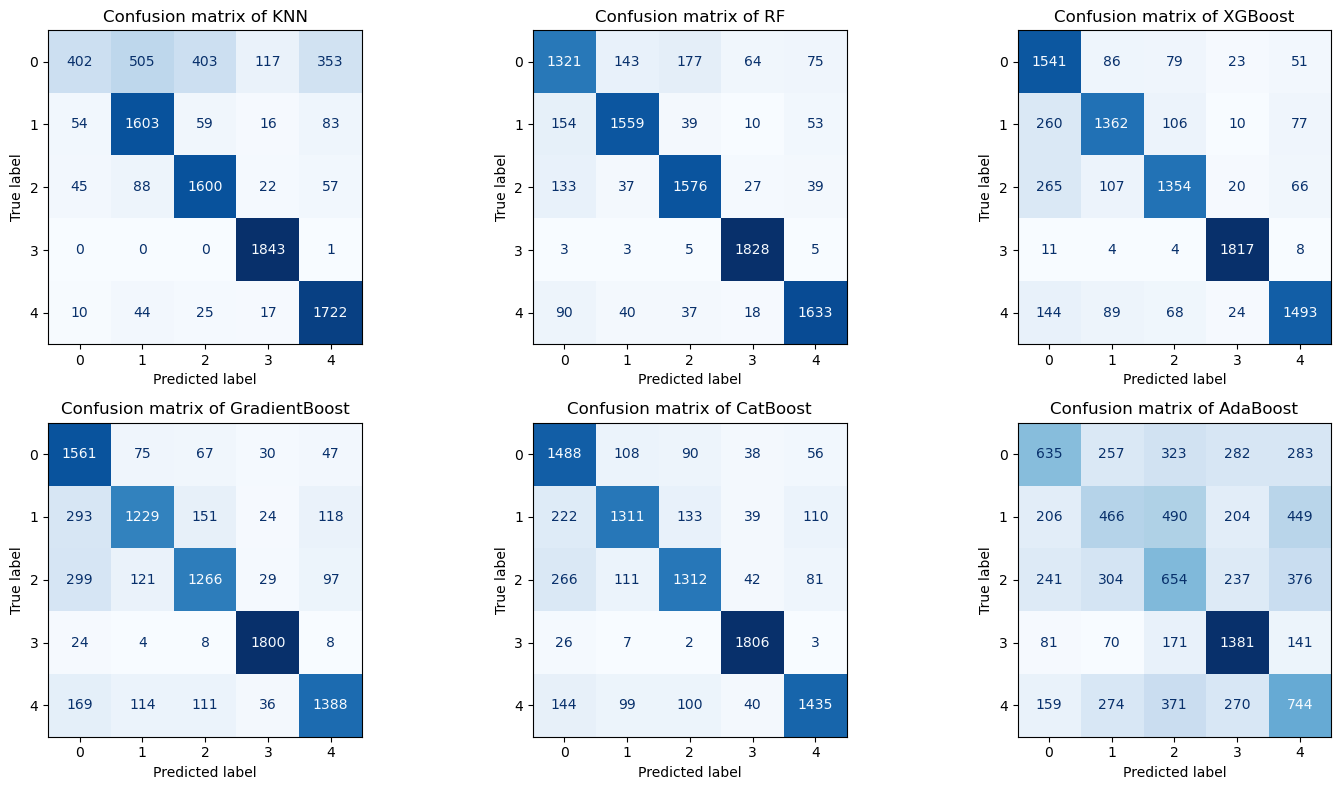

In [51]:
# Figure 7 - confusion matrices on the 20 % holdout, in sample counts.
fig, axes = plt.subplots(2, 3, figsize = (15, 8), squeeze = False)

for ax, (name, result) in zip(axes.ravel(), protocol_b.items()):
    ConfusionMatrixDisplay.from_predictions(
        result["actual"], result["predicted"], labels = CLASS_ORDER,
        values_format = "d", cmap = "Blues", colorbar = False, ax = ax)
    ax.set_title(f"Confusion matrix of {name}")

plt.tight_layout()
plt.show()

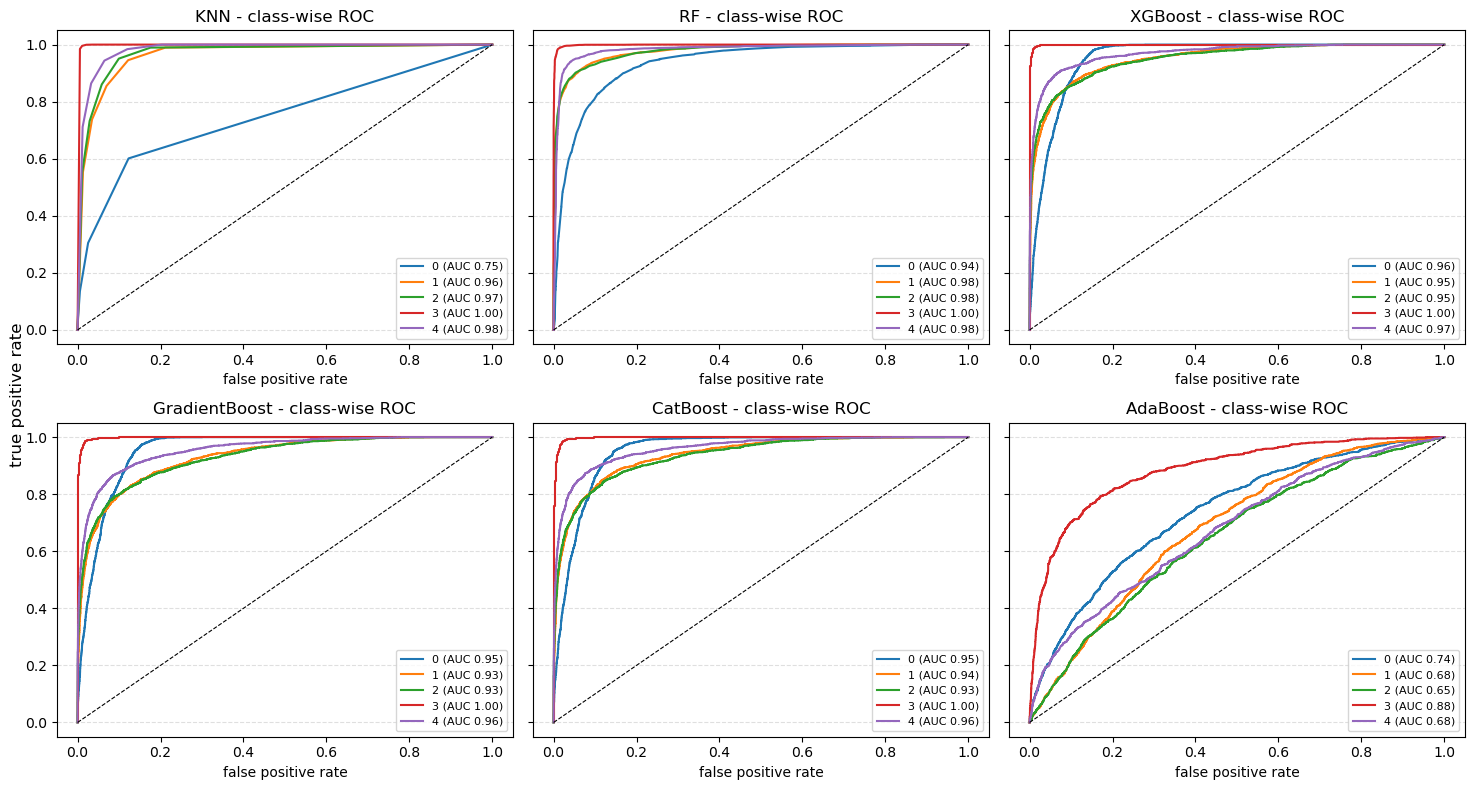

,KNN,RF,XGBoost,GradientBoost,CatBoost,AdaBoost
0,0.751,0.935,0.956,0.953,0.951,0.738
1,0.964,0.978,0.951,0.929,0.939,0.683
2,0.969,0.977,0.950,0.928,0.935,0.649
3,0.997,0.999,0.999,0.998,0.997,0.884
4,0.982,0.983,0.970,0.955,0.960,0.676


In [52]:
# Figure 8 - class-wise ROC, one-vs-rest, on the 20 % holdout.
fig, axes = plt.subplots(2, 3, figsize = (15, 8), squeeze = False, sharey = True)

roc_scores_b = {}

for ax, (name, result) in zip(axes.ravel(), protocol_b.items()):
    binary = label_binarize(result["actual"], classes = CLASS_ORDER)
    scores = {}

    for k, label_code in enumerate(CLASS_ORDER):
        false_positive, true_positive, _ = roc_curve(binary[:, k], result["proba"][:, k])
        area = auc(false_positive, true_positive)
        scores[label_code] = area
        ax.plot(false_positive, true_positive, label = f"{label_code} (AUC {area:.2f})")

    roc_scores_b[name] = scores
    ax.plot([0, 1], [0, 1], "k--", linewidth = 0.8)
    ax.set_title(f"{name} - class-wise ROC")
    ax.set_xlabel("false positive rate")
    ax.grid(True, axis = "y", linestyle = "--", alpha = 0.4)
    ax.legend(loc = "lower right", fontsize = 8)

fig.supylabel("true positive rate")
plt.tight_layout()
plt.show()

pd.DataFrame(roc_scores_b).round(3)

# Comparison against the paper

Per-class values from Tables 6 (KNN), 7 (RF), 9 (XG boost), 10 (gradient boost) and
11 (cat-boost), alongside both protocols, as percentages. `AdaBoost` is in `CLASSIFIERS`
but has no published table, so `COMPARABLE` below restricts the comparison to the five
classifiers the paper actually reports.

In [53]:
# Published per-class metrics in percent, transcribed from Tables 6, 7, 9, 10 and 11.
# Rows follow the Table 5 encoding: NORM 0, MI 1, STTC 2, HYP 3, CD 4.
PAPER = {
    "KNN": pd.DataFrame({"precision": [85, 74, 77, 93, 87],
                         "recall":    [54, 97, 95, 100, 96],
                         "f1":        [56, 84, 85, 96, 91]}, index = CLASS_ORDER),
    "RF":  pd.DataFrame({"precision": [81, 91, 88, 99, 95],
                         "recall":    [86, 86, 89, 99, 93],
                         "f1":        [84, 88, 89, 99, 94]}, index = CLASS_ORDER),
    "XGBoost": pd.DataFrame({"precision": [80, 95, 95, 99, 98],
                             "recall":    [94, 87, 91, 99, 93],
                             "f1":        [86, 91, 93, 99, 96]}, index = CLASS_ORDER),
    # Table 10 is plain gradient boost; reproduction.ipynb runs HistGradientBoost.
    "GradientBoost": pd.DataFrame({"precision": [74, 86, 89, 97, 91],
                                   "recall":    [86, 85, 81, 95, 89],
                                   "f1":        [82, 84, 87, 96, 90]}, index = CLASS_ORDER),
    "CatBoost": pd.DataFrame({"precision": [76, 87, 88, 97, 91],
                              "recall":    [88, 84, 80, 97, 89],
                              "f1":        [81, 83, 86, 97, 90]}, index = CLASS_ORDER),
}

# Table 12, for reference: overall accuracy per classifier.
PAPER_ACCURACY = {"XGBoost": 93.0, "RF": 91.0, "CatBoost": 89.0,
                  "GradientBoost": 88.0, "KNN": 82.0}

# AdaBoost is run here but has no published table, so it sits out the comparison.
COMPARABLE = [name for name in CLASSIFIERS if name in PAPER]

comparison = pd.concat(
    {name: pd.concat({"A: SMOTE in train": protocol_a[name]["report"] * 100,
                      "B: SMOTE before split": protocol_b[name]["report"] * 100,
                      "paper": PAPER[name].astype(float)},
                     names = ["protocol", "class"])
     for name in COMPARABLE},
    names = ["classifier"])

comparison.round(1)

precision  recall    f1
classifier protocol          class                         
KNN        A: SMOTE in train 0           64.9    23.7  34.8
                             1           19.3    33.2  24.4
                             2           19.4    30.5  23.7
                             3           18.9    36.3  24.9
                             4           14.2    30.1  19.3
...                                       ...     ...   ...
CatBoost   paper             0           76.0    88.0  81.0
                             1           87.0    84.0  83.0
                             2           88.0    80.0  86.0
                             3           97.0    97.0  97.0
                             4           91.0    89.0  90.0

[75 rows x 3 columns]

In [54]:
# Each metric side by side, protocol against protocol against the paper.
ORDER = ["A: SMOTE in train", "B: SMOTE before split", "paper"]


def side_by_side(metric):
    return comparison[metric].unstack("protocol")[ORDER].round(1)


for metric in ["recall", "f1"]:
    print(f"\n{metric.upper()} (%)")
    print(side_by_side(metric).to_string())

side_by_side("precision")


RECALL (%)
protocol             A: SMOTE in train  B: SMOTE before split  paper
classifier    class                                                 
KNN           0                   23.7                   22.6   54.0
              1                   33.2                   88.3   97.0
              2                   30.5                   88.3   95.0
              3                   36.3                   99.9  100.0
              4                   30.1                   94.7   96.0
RF            0                   77.5                   74.2   86.0
              1                   28.1                   85.9   86.0
              2                   24.9                   87.0   89.0
              3                   38.7                   99.1   99.0
              4                   26.8                   89.8   93.0
XGBoost       0                   87.7                   86.6   94.0
              1                   27.5                   75.0   87.0
              2       

protocol             A: SMOTE in train  B: SMOTE before split  paper
classifier    class                                                 
KNN           0                   64.9                   78.7   85.0
              1                   19.3                   71.6   74.0
              2                   19.4                   76.7   77.0
              3                   18.9                   91.5   93.0
              4                   14.2                   77.7   87.0
RF            0                   65.7                   77.7   81.0
              1                   39.5                   87.5   91.0
              2                   30.8                   85.9   88.0
              3                   33.1                   93.9   99.0
              4                   38.6                   90.5   95.0
XGBoost       0                   63.9                   69.4   80.0
              1                   46.1                   82.6   95.0
              2                   34.0                   84.0   95.0
              3                   45.6                   95.9   99.0
              4                   44.6                   88.1   98.0
GradientBoost 0                   64.3                   66.5   74.0
              1                   48.6                   79.7   86.0
              2                   36.2                   79.0   89.0
              3                   50.6                   93.8   97.0
              4                   46.0                   83.7   91.0
CatBoost      0                   65.5                   69.3   76.0
              1                   42.4                   80.1   87.0
              2                   36.5                   80.1   88.0
              3                   48.8                   91.9   97.0
              4                   42.5                   85.2   91.0

## Overall comparison (Table 12)

Accuracy, and the mean of the per-class precision, recall and F1, for each protocol
against the published figures. Table 12 supplies the paper's accuracy; its precision,
recall and F1 columns are the means of the per-class tables above.

In [55]:
# Table 12 - one row per classifier and protocol.
def summarise(report, accuracy):
    return {"accuracy": accuracy * 100,
            "precision": report["precision"].mean() * 100,
            "recall": report["recall"].mean() * 100,
            "f1": report["f1"].mean() * 100}


rows = {}

for name in COMPARABLE:
    rows[(name, "A: SMOTE in train")] = summarise(
        protocol_a[name]["report"], protocol_a[name]["accuracy"])
    rows[(name, "B: SMOTE before split")] = summarise(
        protocol_b[name]["report"], protocol_b[name]["accuracy"])
    rows[(name, "paper")] = {"accuracy": PAPER_ACCURACY[name],
                             "precision": PAPER[name]["precision"].mean(),
                             "recall": PAPER[name]["recall"].mean(),
                             "f1": PAPER[name]["f1"].mean()}

summary = pd.DataFrame(rows).T.round(1)
summary.index.names = ["classifier", "protocol"]

summary

accuracy  precision  recall    f1
classifier    protocol                                                
KNN           A: SMOTE in train          27.4       27.3    30.8  25.4
              B: SMOTE before split      79.1       79.2    78.8  75.4
              paper                      82.0       83.2    88.4  82.4
RF            A: SMOTE in train          55.1       41.5    39.2  39.8
              B: SMOTE before split      87.3       87.1    87.2  87.1
              paper                      91.0       90.8    90.6  90.8
XGBoost       A: SMOTE in train          58.6       46.8    36.2  38.8
              B: SMOTE before split      83.4       84.0    83.4  83.4
              paper                      93.0       93.4    92.8  93.0
GradientBoost A: SMOTE in train          59.5       49.1    38.3  41.1
              B: SMOTE before split      79.9       80.5    79.8  79.7
              paper                      88.0       87.4    87.2  87.8
CatBoost      A: SMOTE in train          58.7       47.1    38.7  41.2
              B: SMOTE before split      81.1       81.3    81.0  80.9
              paper                      89.0       87.8    87.6  87.4

## Per-class precision, recall and F1

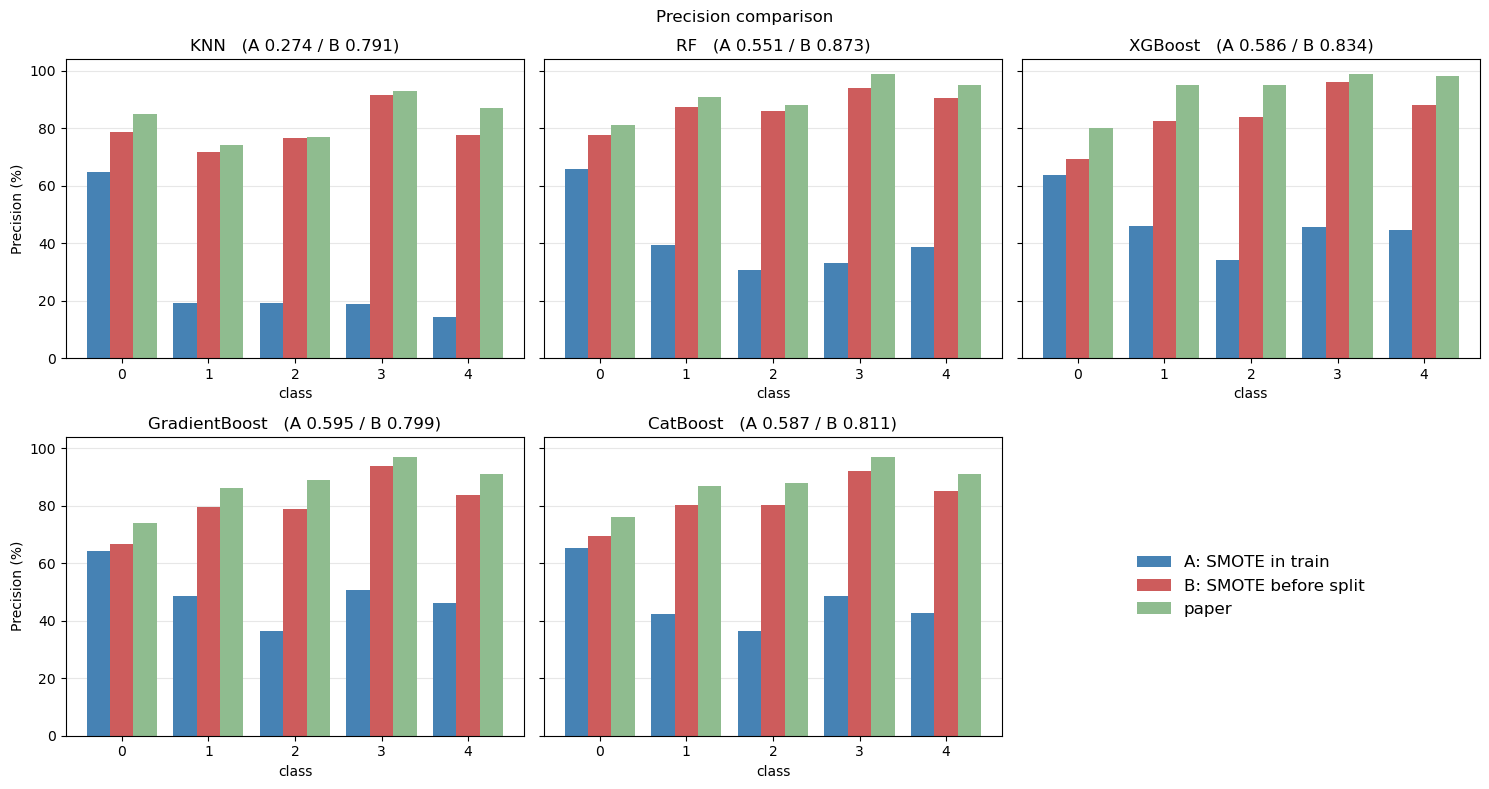

In [56]:
fig, axes = plt.subplots(2, 3, figsize = (15, 8),
                         squeeze = False, sharey = True)

width = 0.27
positions = np.arange(len(CLASS_ORDER))

for ax, name in zip(axes.ravel(), COMPARABLE):
    a = protocol_a[name]["report"]["precision"].values * 100
    b = protocol_b[name]["report"]["precision"].values * 100
    p = PAPER[name]["precision"].values

    ax.bar(positions - width, a, width, label = "A: SMOTE in train", color = "steelblue")
    ax.bar(positions,         b, width, label = "B: SMOTE before split", color = "indianred")
    ax.bar(positions + width, p, width, label = "paper", color = "darkseagreen")

    ax.set_xticks(positions, CLASS_ORDER)
    ax.set_title(f"{name}   (A {protocol_a[name]['accuracy']:.3f} / "
                 f"B {protocol_b[name]['accuracy']:.3f})")
    ax.set_xlabel("class")
    ax.grid(axis = "y", alpha = 0.3)
    ax.set_axisbelow(True)

axes[0][0].set_ylabel("Precision (%)")
axes[1][0].set_ylabel("Precision (%)")

# Hide the unused subplot
axes[1, 2].axis("off")
# Create legend in the empty subplot
handles, labels = axes[0, 0].get_legend_handles_labels()
axes[1, 2].legend(handles, labels, loc = "center", fontsize = 12, frameon = False)

plt.suptitle("Precision comparison")
plt.tight_layout()
plt.show()

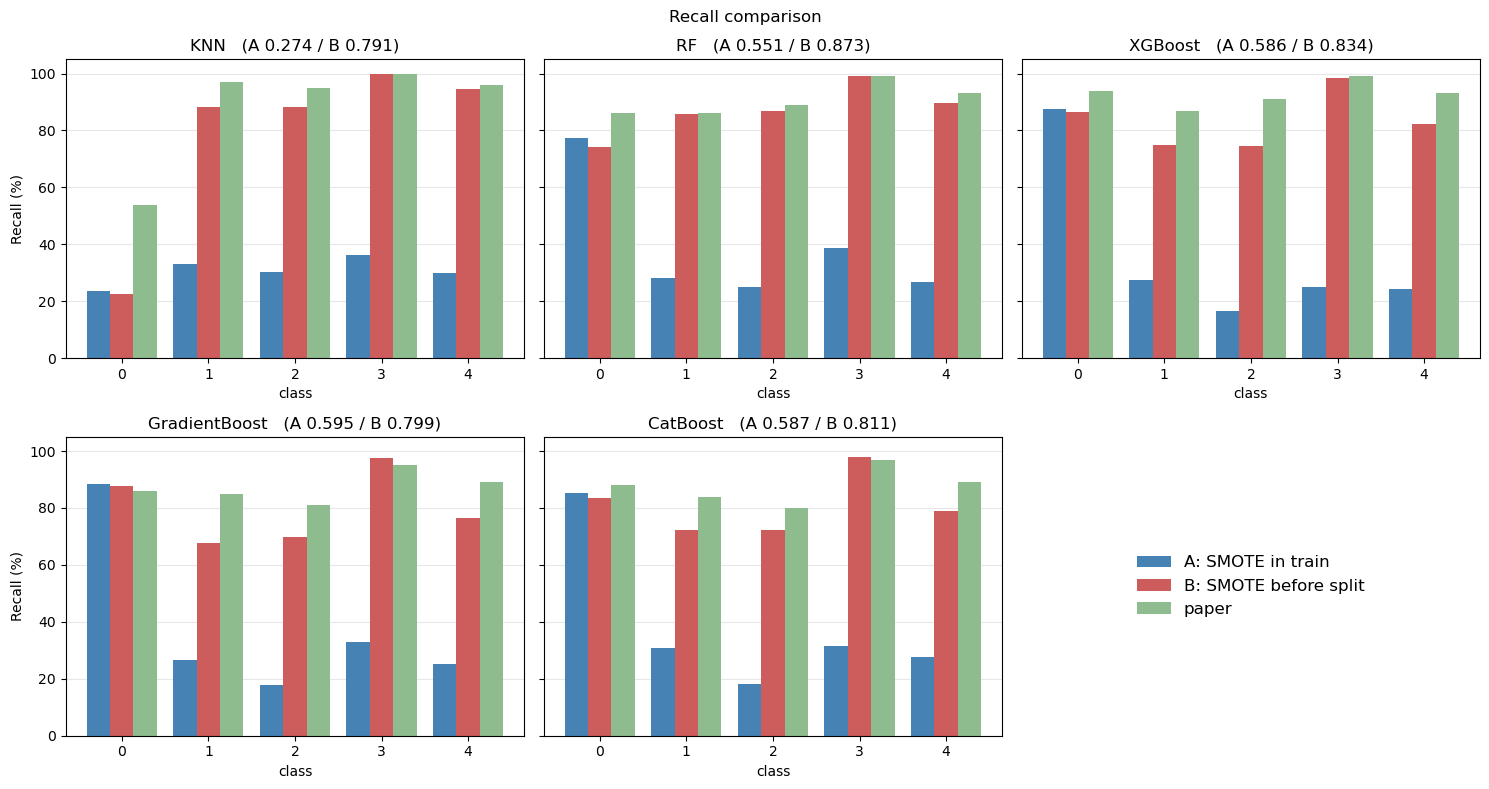

In [57]:
fig, axes = plt.subplots(2, 3, figsize = (15, 8),
                         squeeze = False, sharey = True)

width = 0.27
positions = np.arange(len(CLASS_ORDER))

for ax, name in zip(axes.ravel(), COMPARABLE):
    a = protocol_a[name]["report"]["recall"].values * 100
    b = protocol_b[name]["report"]["recall"].values * 100
    p = PAPER[name]["recall"].values

    ax.bar(positions - width, a, width, label = "A: SMOTE in train", color = "steelblue")
    ax.bar(positions,         b, width, label = "B: SMOTE before split", color = "indianred")
    ax.bar(positions + width, p, width, label = "paper", color = "darkseagreen")

    ax.set_xticks(positions, CLASS_ORDER)
    ax.set_title(f"{name}   (A {protocol_a[name]['accuracy']:.3f} / "
                 f"B {protocol_b[name]['accuracy']:.3f})")
    ax.set_xlabel("class")
    ax.grid(axis = "y", alpha = 0.3)
    ax.set_axisbelow(True)

axes[0][0].set_ylabel("Recall (%)")
axes[1][0].set_ylabel("Recall (%)")

# Hide the unused subplot
axes[1, 2].axis("off")
# Create legend in the empty subplot
handles, labels = axes[0, 0].get_legend_handles_labels()
axes[1, 2].legend(handles, labels, loc = "center", fontsize = 12, frameon = False)

plt.suptitle("Recall comparison")
plt.tight_layout()
plt.show()

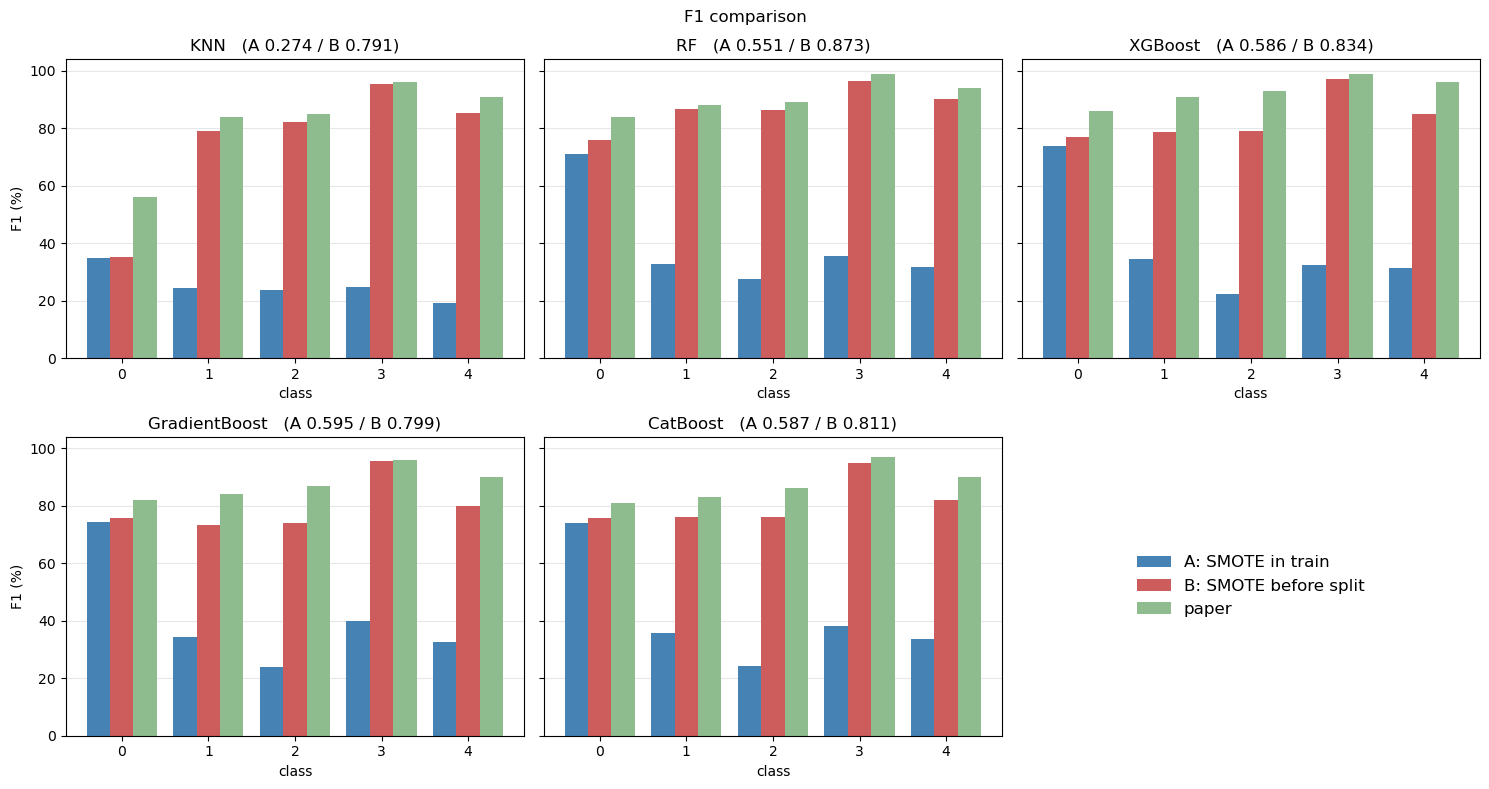

In [61]:
fig, axes = plt.subplots(2, 3, figsize = (15, 8),
                         squeeze = False, sharey = True)

width = 0.27
positions = np.arange(len(CLASS_ORDER))

for ax, name in zip(axes.ravel(), COMPARABLE):
    a = protocol_a[name]["report"]["f1"].values * 100
    b = protocol_b[name]["report"]["f1"].values * 100
    p = PAPER[name]["f1"].values

    ax.bar(positions - width, a, width, label = "A: SMOTE in train", color = "steelblue")
    ax.bar(positions,         b, width, label = "B: SMOTE before split", color = "indianred")
    ax.bar(positions + width, p, width, label = "paper", color = "darkseagreen")

    ax.set_xticks(positions, CLASS_ORDER)
    ax.set_title(f"{name}   (A {protocol_a[name]['accuracy']:.3f} / "
                 f"B {protocol_b[name]['accuracy']:.3f})")
    ax.set_xlabel("class")
    ax.grid(axis = "y", alpha = 0.3)
    ax.set_axisbelow(True)

axes[0][0].set_ylabel("F1 (%)")
axes[1][0].set_ylabel("F1 (%)")

# Hide the unused subplot
axes[1, 2].axis("off")
# Create legend in the empty subplot
handles, labels = axes[0, 0].get_legend_handles_labels()
axes[1, 2].legend(handles, labels, loc = "center", fontsize = 12, frameon = False)

plt.suptitle("F1 comparison")
plt.tight_layout()
plt.show()

## Confusion matrices

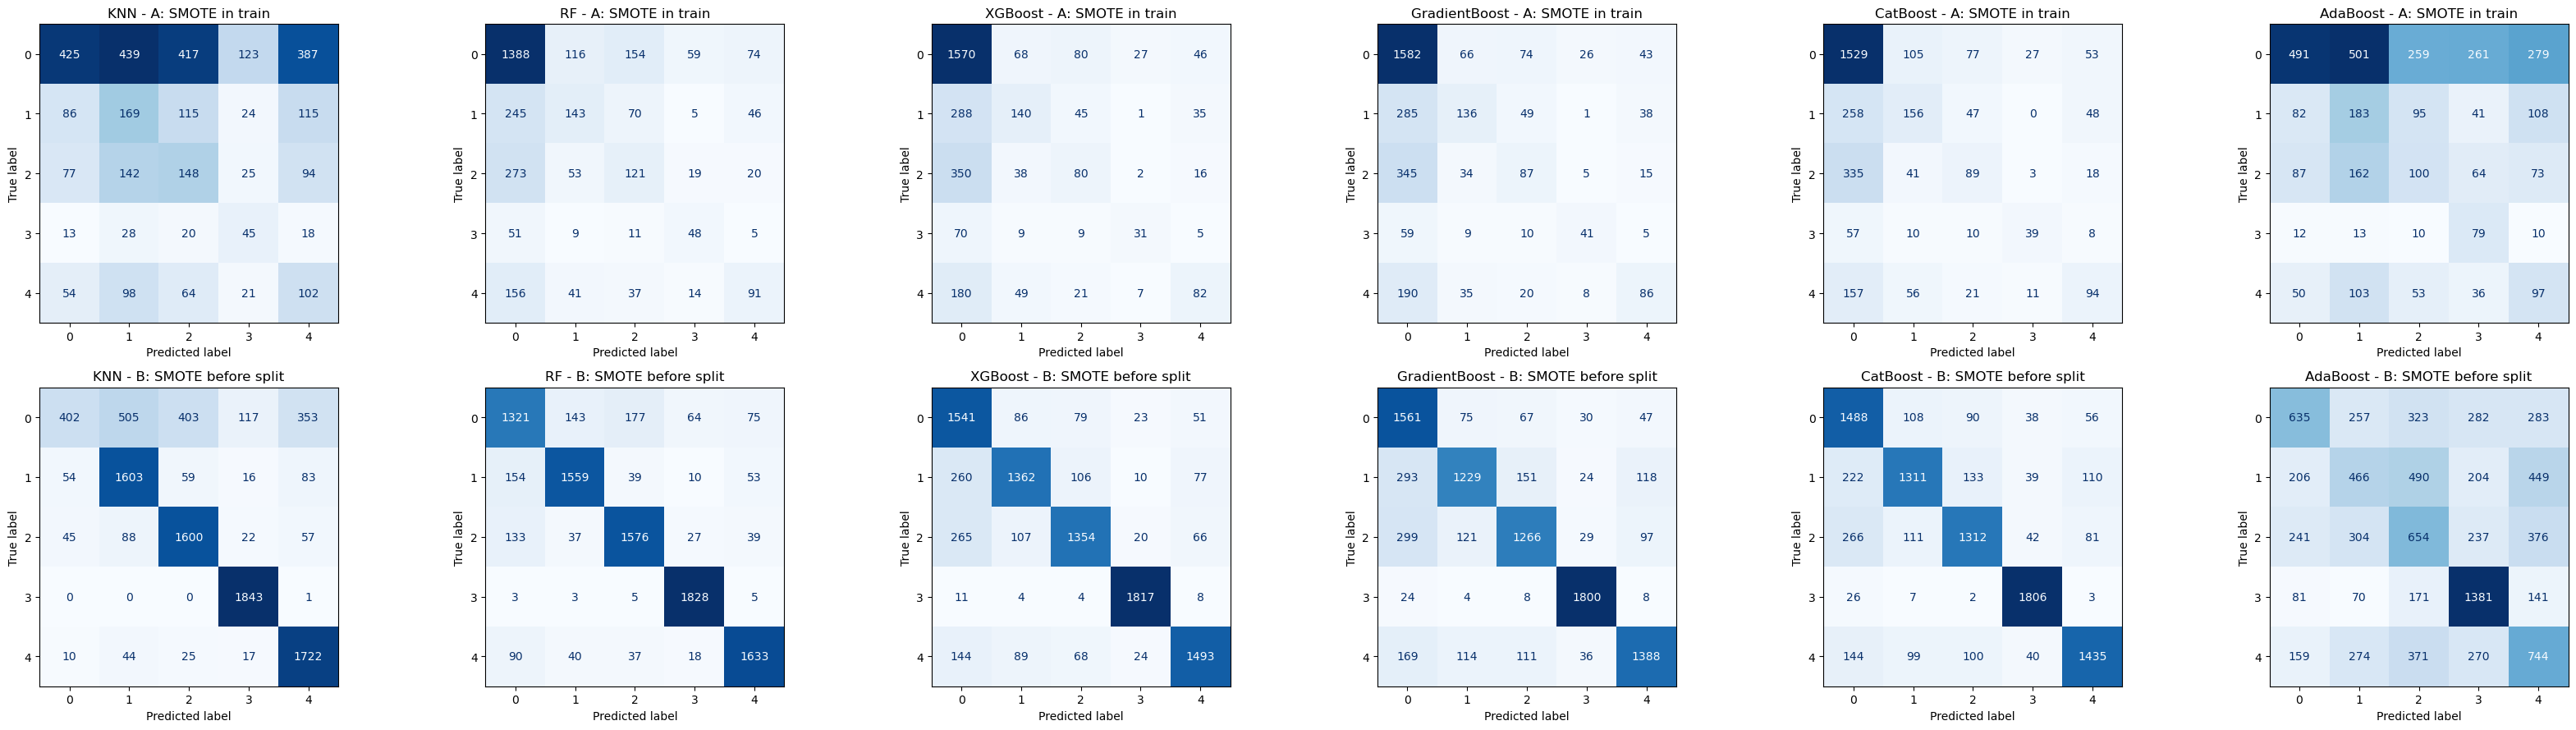

In [59]:
fig, axes = plt.subplots(2, len(CLASSIFIERS), figsize = (5.5 * len(CLASSIFIERS), 9),
                         squeeze = False)

for row, (label, protocol) in enumerate([("A: SMOTE in train", protocol_a),
                                         ("B: SMOTE before split", protocol_b)]):
    for ax, name in zip(axes[row], CLASSIFIERS):
        ConfusionMatrixDisplay.from_predictions(
            protocol[name]["actual"], protocol[name]["predicted"],
            labels = CLASS_ORDER, values_format = "d", cmap = "Blues",
            colorbar = False, ax = ax)
        ax.set_title(f"{name} - {label}")

plt.tight_layout()
plt.show()

## Class-wise ROC (Figure 8)

One-vs-rest ROC per class, for both protocols. The paper reports these for XG boost only,
with AUC above 0.90 for every class and 1.00 for HYP.

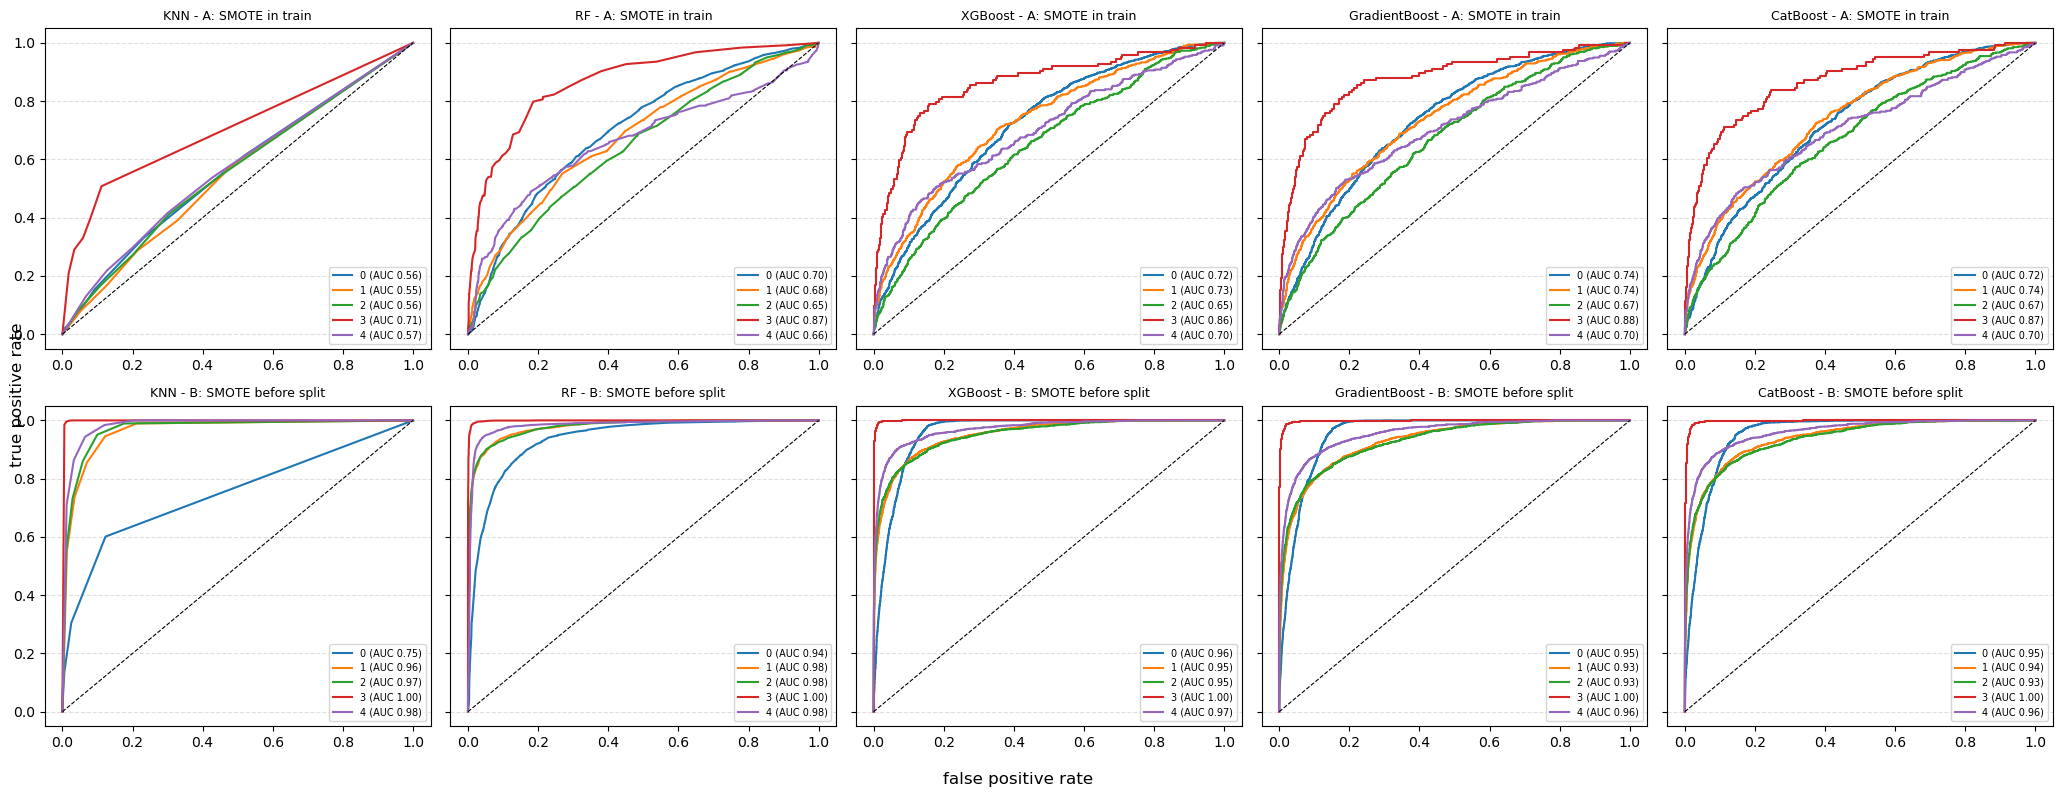

A: SMOTE in train                                        \
                KNN     RF XGBoost GradientBoost CatBoost   
0             0.565  0.702   0.720         0.735    0.724   
1             0.553  0.681   0.729         0.737    0.742   
2             0.560  0.646   0.651         0.670    0.672   
3             0.706  0.868   0.861         0.876    0.866   
4             0.570  0.664   0.698         0.703    0.703   

  B: SMOTE before split                                        
                    KNN     RF XGBoost GradientBoost CatBoost  
0                 0.751  0.935   0.956         0.953    0.951  
1                 0.964  0.978   0.951         0.929    0.939  
2                 0.969  0.977   0.950         0.928    0.935  
3                 0.997  0.999   0.999         0.998    0.997  
4                 0.982  0.983   0.970         0.955    0.960

In [60]:
# Figure 8 - class-wise ROC, one-vs-rest, under both protocols.
fig, axes = plt.subplots(2, len(COMPARABLE), figsize = (4.2 * len(COMPARABLE), 8),
                         squeeze = False, sharey = True)

roc_scores = {}

for row, (label, protocol) in enumerate([("A: SMOTE in train", protocol_a),
                                         ("B: SMOTE before split", protocol_b)]):
    for ax, name in zip(axes[row], COMPARABLE):
        binary = label_binarize(protocol[name]["actual"], classes = CLASS_ORDER)
        scores = {}

        for k, label_code in enumerate(CLASS_ORDER):
            false_positive, true_positive, _ = roc_curve(
                binary[:, k], protocol[name]["proba"][:, k])
            area = auc(false_positive, true_positive)
            scores[label_code] = area
            ax.plot(false_positive, true_positive, label = f"{label_code} (AUC {area:.2f})")

        roc_scores[(label, name)] = scores
        ax.plot([0, 1], [0, 1], "k--", linewidth = 0.8)
        ax.set_title(f"{name} - {label}", fontsize = 9)
        ax.grid(True, axis = "y", linestyle = "--", alpha = 0.4)
        ax.legend(loc = "lower right", fontsize = 7)

fig.supylabel("true positive rate")
fig.supxlabel("false positive rate")
plt.tight_layout()
plt.show()

pd.DataFrame(roc_scores).round(3)